In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import h5py

In [3]:
df_all = pd.read_csv("/Users/jennaisrael/julia/dev/DEBmicroTrait.jl-1/files/output/isolates_batch_model_all.csv")
#/Users/jennaisrael/julia/dev/DEBmicroTrait.jl-1/files/output
#df_all = df_all.dropna()
df_all.head()

,BGE,BP,BR,rgrowth,xenzyme,rGco2,rMco2,rXco2,jEX,jDE,...,alphaenz,gV0,kE,yEV,NSB,KD,yDE,monomer,ontology,eta
0,0.591660,7.888702e-09,2.961760e-09,0.059213,0.000457,0.000261,0.000088,2.014209e-06,0.000007,0.001366,...,0.007718,0.250941,0.990758,1.268776,5.267264e-08,0.008627,0.25,2-aminoisobutyric acid,Amino acids,0.0
1,0.380744,3.192556e-08,1.684607e-08,0.127318,0.000419,0.000630,0.000008,2.072272e-06,0.000002,0.001126,...,0.003288,0.366392,2.247729,2.270981,4.042216e-07,0.037817,0.25,2-aminoisobutyric acid,Amino acids,0.0
2,0.475350,1.560388e-08,7.346933e-09,0.097510,0.000225,0.000470,0.000009,1.085467e-06,0.000002,0.001211,...,0.002309,0.286430,1.695966,1.643836,1.338154e-07,0.011892,0.25,2-aminoisobutyric acid,Amino acids,0.0
3,0.590325,7.447495e-09,3.213237e-09,0.057814,0.000085,0.000253,0.000117,3.711103e-07,0.000001,0.001369,...,0.001464,0.254230,1.088478,1.268776,4.903302e-08,0.008646,0.25,2-aminoisobutyric acid,Amino acids,0.0
4,0.590507,7.873335e-09,3.351377e-09,0.060674,0.000116,0.000246,0.000148,4.680717e-07,0.000002,0.001378,...,0.001904,0.255835,1.132664,1.268776,5.189505e-08,0.009530,0.25,2-aminoisobutyric acid,Amino acids,0.0


In [4]:
df_all['regime'] = np.nan
df_all['regime'][df_all.rgrowth >  0.041] = "high"
df_all['regime'][df_all.rgrowth <  0.04] = "low"

/var/folders/2j/j0k91wbd7lj88qswp8htny9m0000gn/T/ipykernel_45554/1223393504.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all['regime'][df_all.rgrowth >  0.041] = "high"


In [5]:
df_all["jporter"] = df_all['jD']/df_all["NSB"]
df_all["jco2porter"] = df_all['jDEco2']/df_all["NSB"]
df_all["catflux"] = (df_all["kE"]-df_all['rgrowth'])*df_all["dreserve"]
df_all["relrespG"] = df_all["rGco2"]/(df_all["rGco2"] + df_all["rMco2"] + df_all["rXco2"] )
df_all["relrespX"] = df_all["rXco2"]/(df_all["rGco2"] + df_all["rMco2"] + df_all["rXco2"] )
df_all["relrespM"] = df_all["rMco2"]/(df_all["rGco2"] + df_all["rMco2"] + df_all["rXco2"] )

In [6]:
# #Add a column for NSB converted to Vmax

# kcat=180.0*60**2  #inverse hours https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=3&id=114686
# # NSB=np.array(r['NSB']) # mol gC-1, values for 39 strains (rows) on 83 substrates (columns)
# # Vmax_array=NSB*kcat # inverse hours
# df_all["Vmax"]=df_all["NSB"]*kcat

# print(df_all.head())

In [7]:
df_group = df_all.groupby("regime").median()

/var/folders/2j/j0k91wbd7lj88qswp8htny9m0000gn/T/ipykernel_45554/3706662049.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = df_all.groupby("regime").median()


In [8]:
# #skip the step of excluding the undefined responders
# #df_all_pn = df_all.loc[(df_all.response == "positive") | (df_all.response == "negative")]
# df_all_pn = df_all
# df_all_pn_high = df_all_pn.loc[(df_all_pn.regime == 'high')]
# df_all_pn_low = df_all_pn.loc[(df_all_pn.regime == 'low')]

In [9]:
df_filter = df_all.loc[(df_all.monomer == "fumaric acid ") | (df_all.monomer == "glucose") | (df_all.monomer == "abscisic acid")]
# df_filter = df_all.loc[(df_all.monomer == "indole-3-acetic acid") | (df_all.monomer == "thiamine") | (df_all.monomer == "abscisic acid")
#                                              | (df_all.monomer == "sinapyl alcohol") | (df_all.monomer == "jasmonic acid") | (df_all.monomer == "syringic acid")
#                                              | (df_all.monomer == "trans-ferulic acid") | (df_all.monomer == "caffeic acid") | (df_all.monomer == "shikimic acid")
#                                              | (df_all.monomer == "3-Dehydroshikimic acid") | (df_all.monomer == "vanillic acid") | (df_all.monomer == "vanillin")
#                                              | (df_all.monomer == "cis-aconitic acid") | (df_all.monomer == "trans-cinnamic acid") | (df_all.monomer == "2,3-Dihydroxybenzoic acid")
#                                              | (df_all.monomer == "stachyhydrine") | (df_all.monomer == "salicylic acid") | (df_all.monomer == "trigonelline")
#                                              | (df_all.monomer == "alpha-ketoglutaric acid ") | (df_all.monomer == "nicotinic acid") | (df_all.monomer == "malic acid")
#                                              | (df_all.monomer == "succinic acid") | (df_all.monomer == "lactic acid") | (df_all.monomer == "biotin ") 
#                                              | (df_all.monomer == "taurine") | (df_all.monomer == "pantothenic acid ") | (df_all.monomer == "threonic acid")
#                                              ]

In [10]:
# #df_filter_pn = df_filter.loc[(df_filter.response == "positive") | (df_filter.response == "negative")]
df_filter_pn = df_filter

In [11]:
df_filter_pn["jporter"] = df_filter_pn['jDE']/df_filter_pn["NSB"]/1e6
df_filter_pn["relmaint"] = df_filter_pn["rMco2"]/(df_filter_pn["rMco2"] + df_filter_pn["rGco2"] + df_filter_pn["rXco2"])
df_filter_pn["yED"] = 1 - df_filter_pn["yDE"]
df_filter_pn["yVE"] = 1/df_filter_pn["yEV"]
df_filter_pn["alphaenz"] = df_filter_pn["alphaenz"]*1e2

/var/folders/2j/j0k91wbd7lj88qswp8htny9m0000gn/T/ipykernel_45554/2641946209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filter_pn["jporter"] = df_filter_pn['jDE']/df_filter_pn["NSB"]/1e6
/var/folders/2j/j0k91wbd7lj88qswp8htny9m0000gn/T/ipykernel_45554/2641946209.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filter_pn["relmaint"] = df_filter_pn["rMco2"]/(df_filter_pn["rMco2"] + df_filter_pn["rGco2"] + df_filter_pn["rXco2"])
/var/folders/2j/j0k91wbd7lj88qswp8htny9m0000gn/T/ipykernel_45554/

In [12]:
df_filter_pn.head()

,BGE,BP,BR,rgrowth,xenzyme,rGco2,rMco2,rXco2,jEX,jDE,...,regime,jporter,jco2porter,catflux,relrespG,relrespX,relrespM,relmaint,yED,yVE
156,NaN,NaN,3.478387e-10,0.010683,0.000082,2.503750e-07,1.154805e-08,1.932336e-09,7.189386e-09,1.086611e-07,...,low,0.000607,43.321960,0.013886,0.948910,0.007323,0.043767,0.043767,0.933333,0.788161
157,0.401534,4.887986e-09,6.682011e-09,0.043801,0.000144,8.863380e-04,8.082447e-06,2.914377e-06,2.293013e-06,1.604388e-03,...,high,0.130980,9355.685379,0.099829,0.987745,0.003248,0.009007,0.009007,0.933333,0.440338
158,0.304075,1.622480e-10,4.303784e-10,0.005185,0.000012,2.846625e-07,6.027249e-10,6.571883e-10,1.020739e-09,1.951385e-07,...,low,0.000245,17.499194,0.008566,0.995594,0.002298,0.002108,0.002108,0.933333,0.608333
159,0.710141,2.292450e-09,9.056098e-10,0.022441,0.000033,3.779157e-04,1.451476e-04,5.533690e-07,2.058846e-06,1.987651e-03,...,low,0.593792,42413.706864,0.028752,0.721741,0.001057,0.277202,0.277202,0.933333,0.788161
160,0.703528,2.011499e-09,8.360966e-10,0.020363,0.000039,3.602629e-04,1.898348e-04,6.859793e-07,2.552231e-06,1.950139e-03,...,low,0.652903,46635.909179,0.026186,0.654091,0.001245,0.344663,0.344663,0.933333,0.788161


In [13]:
df_filter_pn.shape

(117, 44)

In [14]:
df_filter_pn.set_index("isolate", inplace = True)

In [15]:
df_filter_pn.iloc[0]

BGE                     NaN
BP                      NaN
BR                      0.0
rgrowth            0.010683
xenzyme            0.000082
rGco2                   0.0
rMco2                   0.0
rXco2                   0.0
jEX                     0.0
jDE                     0.0
jDEco2                  0.0
jD                      0.0
jED                     0.0
jV                      0.0
jE                      0.0
dreserve           0.014169
response           positive
class         Acidobacteria
phylum        Acidobacteria
mingt                   7.0
rrn                       3
genomesize          6679185
kM                 0.000173
alphaenz           0.771777
gV0                0.250941
kE                 0.990758
yEV                1.268776
NSB                     0.0
KD                 0.001513
yDE                0.066667
monomer       abscisic acid
ontology      Organic acids
eta                     0.0
regime                  low
jporter            0.000607
jco2porter         4

In [16]:
#result = df.loc[["Stuti", "Seema"],
 #           ["City", "Salary"]]
df_filter_pn.loc[['Pseudomonas sp. URHB0015','Paenibacillus sp. URHA0014'],['monomer','yED','response','ontology','rrn','BGE','rgrowth','mingt','NSB']]

,monomer,yED,response,ontology,rrn,BGE,rgrowth,mingt,NSB
isolate,,,,,,,,,
Pseudomonas sp. URHB0015,abscisic acid,0.933333,positive,Organic acids,8,0.567081,0.073662,0.96,1.624711e-08
Pseudomonas sp. URHB0015,fumaric acid,0.643333,positive,Organic acids,8,0.386920,0.076300,0.96,8.839102e-08
Pseudomonas sp. URHB0015,glucose,0.821667,positive,Sugars,8,0.506984,0.103711,0.96,6.920676e-08
Paenibacillus sp. URHA0014,abscisic acid,0.933333,negative,Organic acids,23,0.329097,0.016282,1.43,4.452854e-09
Paenibacillus sp. URHA0014,fumaric acid,0.643333,negative,Organic acids,23,0.220145,0.016266,1.43,2.422537e-08
Paenibacillus sp. URHA0014,glucose,0.821667,negative,Sugars,23,0.418859,0.120996,1.43,3.709206e-07


In [17]:
kcat=180.0*60**2  #inverse hours https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=3&id=114686

In [18]:
mask1 = df_filter_pn.monomer == 'abscisic acid'
df_AbA=df_filter_pn[mask1].loc[:,['BGE','rgrowth','rrn','NSB']]
df_AbA['Vmax']=df_AbA['NSB']*kcat*15 #15 carbons in abA
print(df_AbA)


# print(df[mask])
# df_filter_pn.loc['monomer'=='abscisic acid']

                                             BGE   rgrowth  rrn           NSB  \
isolate                                                                         
Acidobacteriaceae bacterium URHE0068         NaN  0.010683    3  1.791586e-10   
Bacillus sp. URHB0009                   0.401534  0.043801   20  1.224914e-08   
Blastococcus sp. URHD0036               0.304075  0.005185    8  7.965204e-10   
Bradyrhizobium sp. URHA0002             0.710141  0.022441    3  3.347387e-09   
Bradyrhizobium sp. URHA0013             0.703528  0.020363    3  2.986876e-09   
Bradyrhizobium sp. URHD0069             0.709621  0.021943    3  3.264816e-09   
Burkholderia sp. URHA0054               0.496478  0.023160   10  4.693112e-09   
Caulobacter sp. URHA0033                0.719501  0.031771    3  4.795313e-09   
Cellulomonas sp. URHD0024                    NaN  0.009418    8  4.835261e-10   
Cellulomonas sp. URHE0023                    NaN  0.005487    5  2.855628e-10   
Comamonadaceae bacterium URH

In [19]:
# fig_width = 4.5                        # inches  
# golden_mean = (np.sqrt(5)-1.0)/2.0      # Aesthetic ratio
# fig_height = 3.5      # height in inches
# dpi = 300.0  
# # Margins are specified as a fraction of axes size.
# # May need to adjust (especially left and bottom) to accomodate axes labels/tickmarks
# leftmargin = 0.15
# bottommargin = 0.2
# rightmargin = 0.05
# topmargin = 0.1
# # These two parameters are used for adjusting spacing between subplots (when used)
# wspace = 0.2
# hspace = 0.2

# fig_size =  [fig_width,fig_height]
# params = {'backend': 'svg',
#           'axes.labelsize': 12,
#           'axes.titlesize': 12,
#           'legend.fontsize': 10,
#           'xtick.labelsize': 12,
#           'ytick.labelsize': 12,
#           'figure.figsize': fig_size,
#           'text.usetex': False, 
#           'font.family':'sans-serif',
#           'font.sans-serif':'Arial',
#           'svg.fonttype':'none'}

In [20]:
for i,r in df_AbA.iterrows():
    print(r.BGE)

nan
0.4015340467801271
0.3040754731771417
0.7101411568915443
0.7035281061979314
0.7096207461970824
0.4964783334913124
0.7195013354291868
nan
nan
0.6435461829556072
0.4178924886300454
0.5604354902799633
0.4990851120475967
0.4524140225035612
0.5036010817898752
0.5787694544961567
0.6242803382706228
0.5698142479397308
0.5229937909353735
0.4154892984702109
nan
0.5603523372729533
nan
0.4757876824629927
0.5057933536731113
0.4015286215080537
nan
0.3290971208708716
0.5670811454055789
0.7068335375040449
0.4212735674115239
nan
nan
0.6821791844590572
0.7168975780508975
0.4919342879737254
0.2623398906305451
0.487854061984004


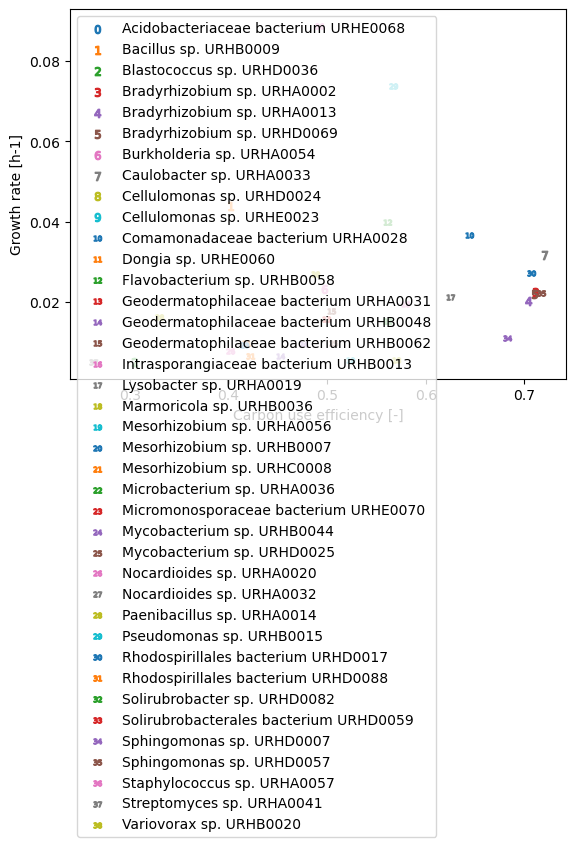

In [21]:
fig, ax1 = plt.subplots() 

count=0
for i,r in df_AbA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.BGE,r.rgrowth,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax1.set(ylabel='Growth rate [h-1]', xlabel='Carbon use efficiency [-]')

plt.legend()
plt.show()

In [22]:
mask2 = df_filter_pn.monomer == 'fumaric acid '
df_FA=df_filter_pn[mask2].loc[:,['BGE','rgrowth','rrn','NSB']]
df_FA['Vmax']=df_FA['NSB']*kcat*4 #multiply by carbon stoichiometry

mask3 = df_filter_pn.monomer == 'glucose'
df_G=df_filter_pn[mask3].loc[:,['BGE','rgrowth','rrn','NSB']]
df_G['Vmax']=df_G['NSB']*kcat*6

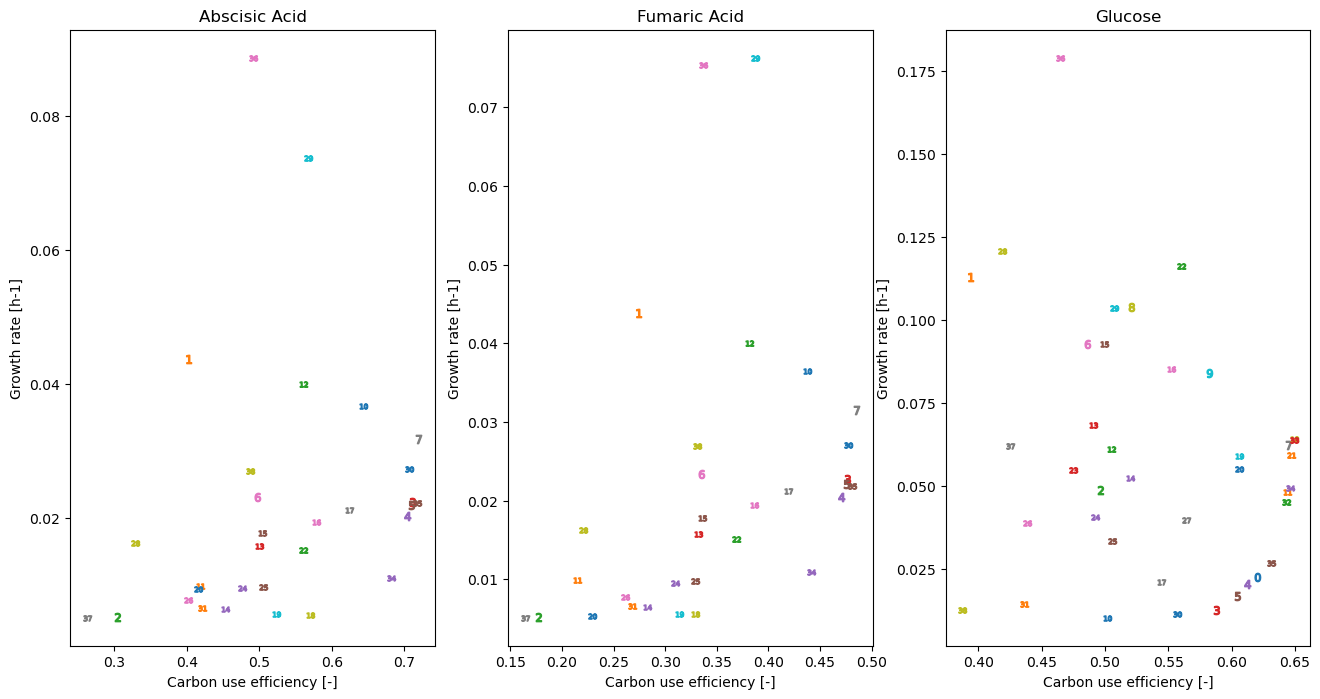

In [23]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(16,8)) 

count=0
for i,r in df_AbA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.BGE,r.rgrowth,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax1.set(ylabel='Growth rate [h-1]', xlabel='Carbon use efficiency [-]')
ax1.set_title('Abscisic Acid')


count=0
for i,r in df_FA.iterrows():
    #print(r.BGE)
    ax2.scatter(r.BGE,r.rgrowth,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax2.set(ylabel='Growth rate [h-1]', xlabel='Carbon use efficiency [-]')
ax2.set_title('Fumaric Acid')

count=0
for i,r in df_G.iterrows():
    #print(r.BGE)
    ax3.scatter(r.BGE,r.rgrowth,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax3.set(ylabel='Growth rate [h-1]', xlabel='Carbon use efficiency [-]')
ax3.set_title('Glucose')

#plt.legend()
plt.show()

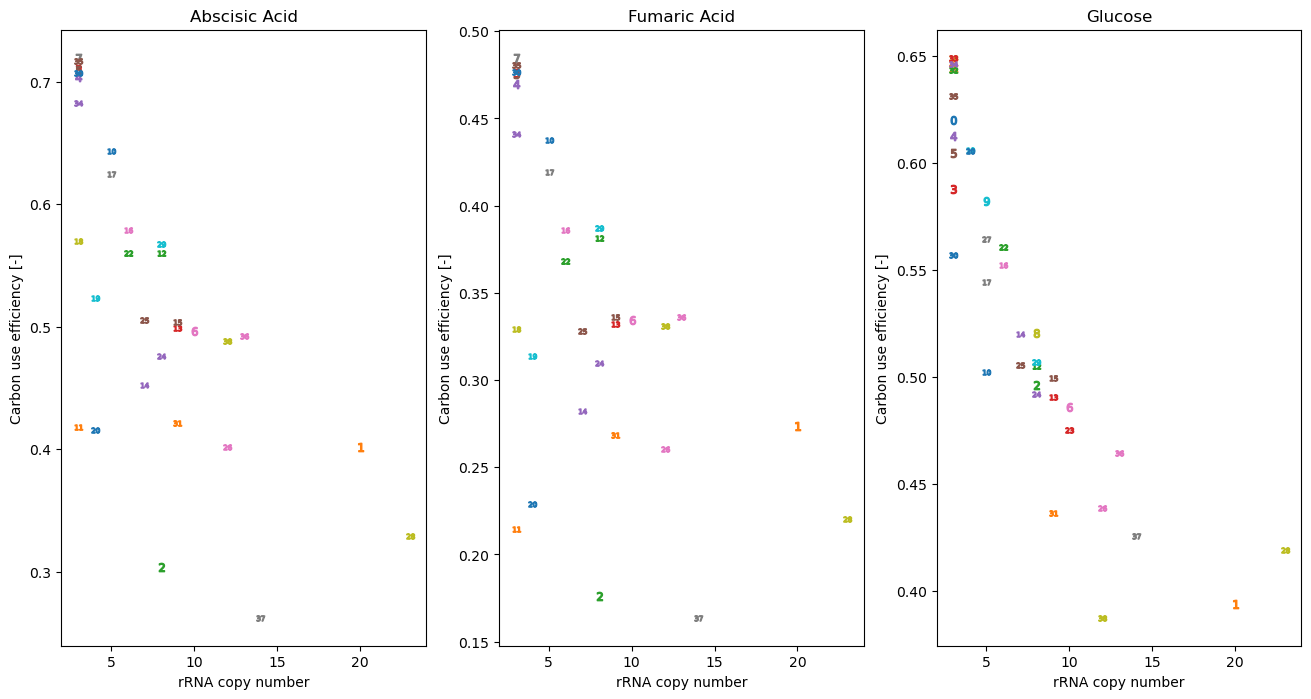

In [24]:
#make a plot of rRNA copy number and BGE in the 3 carbon sources
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(16,8)) 
count=0
for i,r in df_AbA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.rrn,r.BGE,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax1.set(xlabel='rRNA copy number', ylabel='Carbon use efficiency [-]')
ax1.set_title('Abscisic Acid')
#ax1.legend()

count=0
for i,r in df_FA.iterrows():
    #print(r.BGE)
    ax2.scatter(r.rrn,r.BGE,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax2.set(xlabel='rRNA copy number', ylabel='Carbon use efficiency [-]')
ax2.set_title('Fumaric Acid')
#ax2.legend()

count=0
for i,r in df_G.iterrows():
    #print(r.BGE)
    ax3.scatter(r.rrn,r.BGE,label=i,marker="$"+str(count)+"$")
    count=count+1
    ax3.set(xlabel='rRNA copy number', ylabel='Carbon use efficiency [-]')
ax3.set_title('Glucose')
#ax3.legend()

#plt.legend()
plt.show()


In [25]:
# #Add a column for NSB converted to Vmax

# kcat=180.0*60**2  #inverse hours https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=3&id=114686
# # NSB=np.array(r['NSB']) # mol gC-1, values for 39 strains (rows) on 83 substrates (columns)
# # Vmax_array=NSB*kcat # inverse hours
# r.Vmax=r.NSB*kcat

# print(r.head())

In [26]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

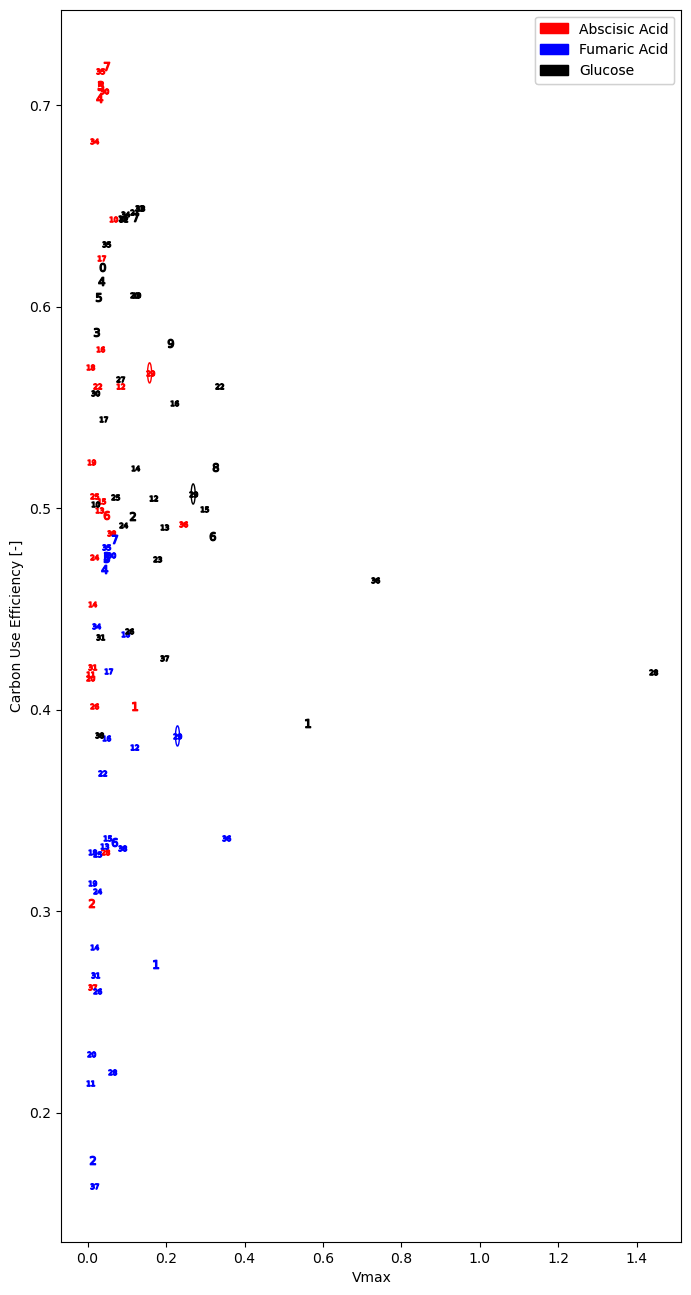

In [27]:
#Plot Vmax and CUE for each strain on all 3 carbon sources on one set of axes. Make all the number markers on one C source the same color.

#make a plot of rRNA copy number and BGE in the 3 carbon sources
fig, (ax1) = plt.subplots(figsize=(8,16)) 
count=0
for i,r in df_AbA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='r')
    if count==29:
        c1=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='r' )
        ax1.add_patch(c1)
    count=count+1
    ax1.set(xlabel='Vmax', ylabel='Carbon Use Efficiency [-]')

#ax1.legend()

count=0
for i,r in df_FA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='b')
    if count==29:
        c2=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='b' )
        ax1.add_patch(c2)
    count=count+1

#ax2.legend()

count=0
for i,r in df_G.iterrows():
    #print(r.BGE)
    ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='k')
    if count==29:
        c3=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='k' )
        ax1.add_patch(c3)
    count=count+1
   
# Create each entry for legend of linestyles
# new_style = Line2D([0], [0], linewidth=3, color='black', linestyle='LINESTYLE HERE', label='LABEL NAME HERE')
red_patch = mpatches.Patch( color='red', label='Abscisic Acid')
blue_patch =mpatches.Patch( color='blue', label='Fumaric Acid')
black_patch = mpatches.Patch(color='black', label='Glucose')

# Create legend of colors
ax1.add_artist(plt.legend(handles=[red_patch, blue_patch, black_patch],loc='upper right'))


#ax1.legend()

#plt.legend()
plt.show()



In [28]:
count=21
ed_idx=np.array([21,17,34,22,20,7,19])
if count in ed_idx:
    print('yes')

yes


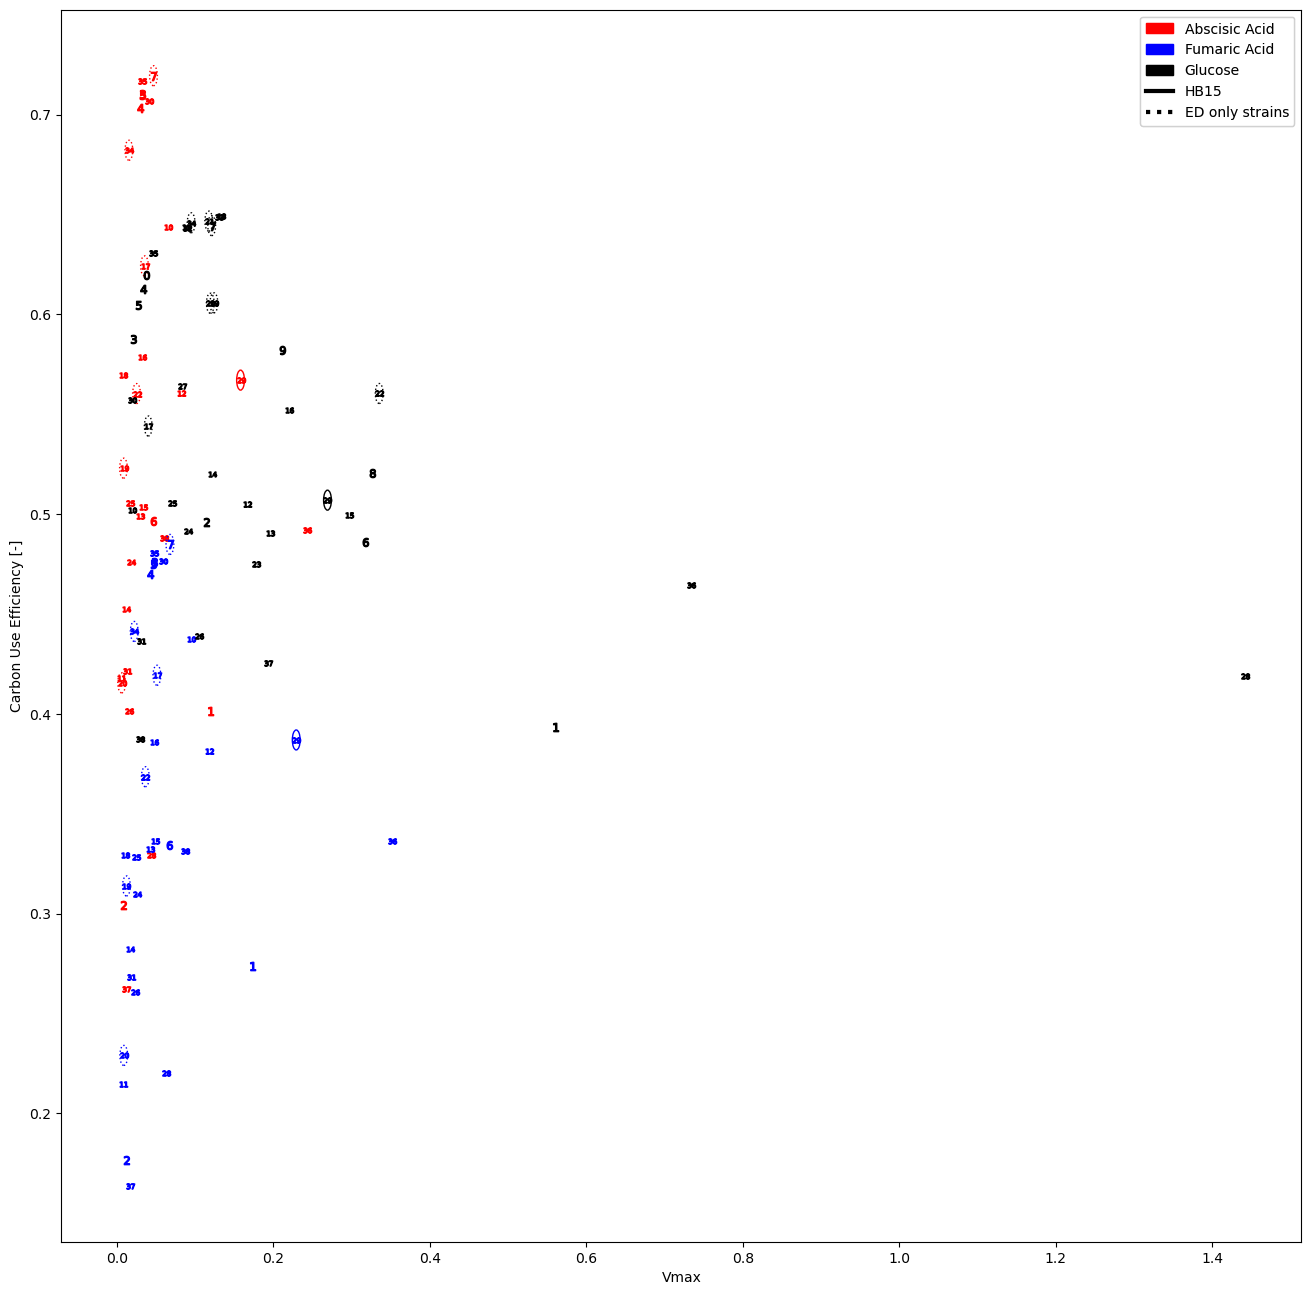

In [29]:
# add circles around the other strains with only ED pathway

#HC08 (21)
# HA19 (17)
# HD07 (34)
# HB36 (22)
# HB07 (20)
# HA33 (7)
# HA56 (19)

ed_idx=np.array([21,17,34,22,20,7,19])

#make a plot of rRNA copy number and BGE in the 3 carbon sources
fig, (ax1) = plt.subplots(figsize=(16,16)) 
count=0
for i,r in df_AbA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='r')
    if count==29:
        c1=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='r' )
        ax1.add_patch(c1)
    elif count in ed_idx:
        c4=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='r',linestyle=':' )
        ax1.add_patch(c4)
    count=count+1
    ax1.set(xlabel='Vmax', ylabel='Carbon Use Efficiency [-]')

#ax1.legend()

count=0
for i,r in df_FA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='b')
    if count==29:
        c2=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='b' )
        ax1.add_patch(c2)
    elif count in ed_idx:
        c5=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='b',linestyle=':' )
        ax1.add_patch(c5)
    count=count+1

#ax2.legend()

count=0
for i,r in df_G.iterrows():
    #print(r.BGE)
    ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='k')
    if count==29:
        c3=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='k' )
        ax1.add_patch(c3)
    elif count in ed_idx:
        c6=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='k', linestyle=':' )
        ax1.add_patch(c6)
    count=count+1

# #plot CUE=Vmax^1/-1.7
# x=np.linspace(0.05,1.4,num=20)
# ax1.plot(x,x**(-1/1.7),color='k',linestyle='--')

   
# Create each entry for legend of linestyles
# new_style = Line2D([0], [0], linewidth=3, color='black', linestyle='LINESTYLE HERE', label='LABEL NAME HERE')
red_patch = mpatches.Patch( color='red', label='Abscisic Acid')
blue_patch =mpatches.Patch( color='blue', label='Fumaric Acid')
black_patch = mpatches.Patch(color='black', label='Glucose')

solid_line=Line2D([0], [0], linewidth=3, color='black', linestyle='-', label='HB15')
dotted_line=Line2D([0], [0], linewidth=3, color='black', linestyle=':', label='ED only strains')
#dashed_line=Line2D([0], [0], linewidth=3, color='black', linestyle='--', label='Calabrese et al.')

# Create legend of colors
ax1.add_artist(plt.legend(handles=[red_patch, blue_patch, black_patch,solid_line,dotted_line],loc='upper right'))


#ax1.legend()

#plt.legend()
plt.show()



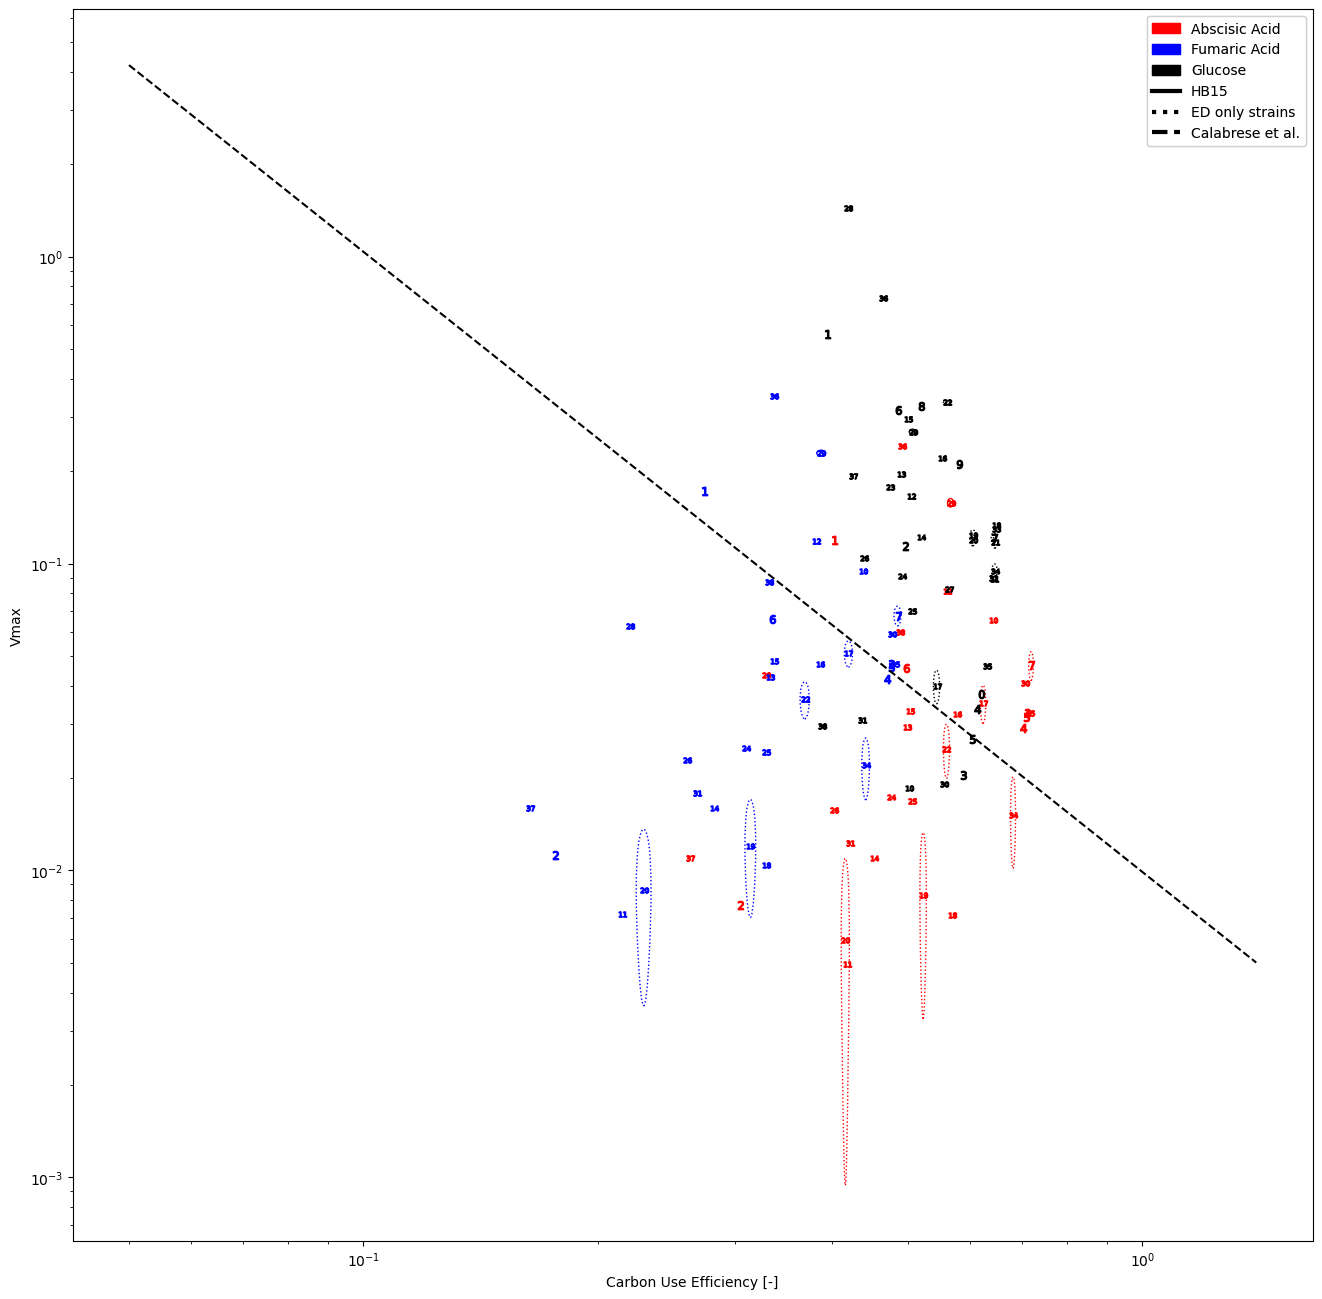

In [30]:
# add circles around the other strains with only ED pathway

#HC08 (21)
# HA19 (17)
# HD07 (34)
# HB36 (22)
# HB07 (20)
# HA33 (7)
# HA56 (19)

ed_idx=np.array([21,17,34,22,20,7,19])

#make a plot of rRNA copy number and BGE in the 3 carbon sources
fig, (ax1) = plt.subplots(figsize=(16,16)) 
count=0
for i,r in df_AbA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.BGE,r.Vmax,label=i,marker="$"+str(count)+"$",color='r')
    if count==29:
        c1=plt.Circle((r.BGE,r.Vmax), 0.005, fill = False,color='r' )
        ax1.add_patch(c1)
    elif count in ed_idx:
        c4=plt.Circle((r.BGE,r.Vmax), 0.005, fill = False,color='r',linestyle=':' )
        ax1.add_patch(c4)
    count=count+1
    ax1.set(ylabel='Vmax', xlabel='Carbon Use Efficiency [-]')

#ax1.legend()

count=0
for i,r in df_FA.iterrows():
    #print(r.BGE)
    ax1.scatter(r.BGE, r.Vmax,label=i,marker="$"+str(count)+"$",color='b')
    if count==29:
        c2=plt.Circle((r.BGE, r.Vmax), 0.005, fill = False,color='b' )
        ax1.add_patch(c2)
    elif count in ed_idx:
        c5=plt.Circle((r.BGE, r.Vmax), 0.005, fill = False,color='b',linestyle=':' )
        ax1.add_patch(c5)
    count=count+1

#ax2.legend()

count=0
for i,r in df_G.iterrows():
    #print(r.BGE)
    ax1.scatter(r.BGE,r.Vmax,label=i,marker="$"+str(count)+"$",color='k')
    if count==29:
        c3=plt.Circle((r.BGE,r.Vmax), 0.005, fill = False,color='k' )
        ax1.add_patch(c3)
    elif count in ed_idx:
        c6=plt.Circle((r.BGE,r.Vmax), 0.005, fill = False,color='k', linestyle=':' )
        ax1.add_patch(c6)
    count=count+1


ax1.set_yscale('log')
ax1.set_xscale('log')


# #plot CUE=Vmax^1/-1.7
x=np.linspace(0.05,1.4,num=20)
# ax1.plot(x,x**(-1/1.7),color='k',linestyle='--')

slope=-2.021
intercept=-2.005
y=10**intercept*x**slope

ax1.plot(x,y,color='k',linestyle='--') #Calabrese
   
# Create each entry for legend of linestyles
# new_style = Line2D([0], [0], linewidth=3, color='black', linestyle='LINESTYLE HERE', label='LABEL NAME HERE')
red_patch = mpatches.Patch( color='red', label='Abscisic Acid')
blue_patch =mpatches.Patch( color='blue', label='Fumaric Acid')
black_patch = mpatches.Patch(color='black', label='Glucose')

solid_line=Line2D([0], [0], linewidth=3, color='black', linestyle='-', label='HB15')
dotted_line=Line2D([0], [0], linewidth=3, color='black', linestyle=':', label='ED only strains')
dashed_line=Line2D([0], [0], linewidth=3, color='black', linestyle='--', label='Calabrese et al.')

# Create legend of colors
ax1.add_artist(plt.legend(handles=[red_patch, blue_patch, black_patch,solid_line,dotted_line,dashed_line],loc='upper right'))


#ax1.legend()

#plt.legend()
plt.show()


In [31]:
# df_AbA.to_csv("Abscisic_file.csv",sep='\t')
# df_FA.to_csv("Fumaric_acid_file.csv",sep='\t')
# df_G.to_csv("Glucose_file.csv",sep='\t')

,BGE,rgrowth,rrn,NSB,Vmax
isolate,,,,,
Acidobacteriaceae bacterium URHE0068,NaN,0.010683,3,1.791586e-10,0.001741
Bacillus sp. URHB0009,0.401534,0.043801,20,1.224914e-08,0.119062
Blastococcus sp. URHD0036,0.304075,0.005185,8,7.965204e-10,0.007742
Bradyrhizobium sp. URHA0002,0.710141,0.022441,3,3.347387e-09,0.032537
Bradyrhizobium sp. URHA0013,0.703528,0.020363,3,2.986876e-09,0.029032


In [33]:
# # add circles around the other strains with only EMP pathway

# #HC08 (21)
# # HA19 (17)
# # HD07 (34)
# # HB36 (22)
# # HB07 (20)
# # HA33 (7)
# # HA56 (19)

# emp_idx=np.array([21,17,34,22,20,7,19])

# #make a plot of rRNA copy number and BGE in the 3 carbon sources
# fig, (ax1) = plt.subplots(figsize=(8,16)) 
# count=0
# for i,r in df_AbA.iterrows():
#     #print(r.BGE)
#     ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='r')
#     if count==29:
#         c1=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='r' )
#         ax1.add_patch(c1)
#     elif count in ed_idx:
#         c4=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='r',linestyle=':' )
#         ax1.add_patch(c4)
#     count=count+1
#     ax1.set(xlabel='Vmax', ylabel='Carbon Use Efficiency [-]')

# #ax1.legend()

# count=0
# for i,r in df_FA.iterrows():
#     #print(r.BGE)
#     ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='b')
#     if count==29:
#         c2=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='b' )
#         ax1.add_patch(c2)
#     elif count in ed_idx:
#         c5=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='b',linestyle=':' )
#         ax1.add_patch(c5)
#     count=count+1

# #ax2.legend()

# count=0
# for i,r in df_G.iterrows():
#     #print(r.BGE)
#     ax1.scatter(r.Vmax,r.BGE,label=i,marker="$"+str(count)+"$",color='k')
#     if count==29:
#         c3=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='k' )
#         ax1.add_patch(c3)
#     elif count in ed_idx:
#         c6=plt.Circle((r.Vmax,r.BGE), 0.005, fill = False,color='k', linestyle=':' )
#         ax1.add_patch(c6)
#     count=count+1
   
# # Create each entry for legend of linestyles
# # new_style = Line2D([0], [0], linewidth=3, color='black', linestyle='LINESTYLE HERE', label='LABEL NAME HERE')
# red_patch = mpatches.Patch( color='red', label='Abscisic Acid')
# blue_patch =mpatches.Patch( color='blue', label='Fumaric Acid')
# black_patch = mpatches.Patch(color='black', label='Glucose')

# solid_line=Line2D([0], [0], linewidth=3, color='black', linestyle='-', label='HB15')
# dotted_line=Line2D([0], [0], linewidth=3, color='black', linestyle=':', label='ED only strains')

# # Create legend of colors
# ax1.add_artist(plt.legend(handles=[red_patch, blue_patch, black_patch,solid_line,dotted_line],loc='upper right'))


# #ax1.legend()

# #plt.legend()
# plt.show()



In [ ]:
#add media column to 
df_AbA['C_Source']=

In [34]:
#make a dataframe with Vmax, CUE, C source, glycolysis pathway, Strain name 

df_choose=

SyntaxError: invalid syntax (619942101.py, line 3)